In [4]:
from google.colab import files

uploaded = files.upload()

Saving time_series_60min_singleindex.csv to time_series_60min_singleindex.csv


In [58]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint

pd.set_option('display.max_columns', None)

In [59]:
#dataset load
df = pd.read_csv('time_series_60min_singleindex.csv')

print(df.shape)
df.head()

(50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,BG_load_actual_entsoe_transparency,BG_load_forecast_entsoe_transparency,BG_solar_generation_actual,BG_wind_onshore_generation_actual,CH_load_actual_entsoe_transparency,CH_load_forecast_entsoe_transparency,CH_solar_capacity,CH_solar_generation_actual,CH_wind_onshore_capacity,CH_wind_onshore_generation_actual,CY_load_actual_entsoe_transparency,CY_load_forecast_entsoe_transparency,CY_wind_onshore_generation_actual,CZ_load_actual_entsoe_transparency,CZ_load_forecast_entsoe_transparency,CZ_solar_generation_actual,CZ_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,DE_50hertz_load_actual_entsoe_transparency,DE_50hertz_load_forecast_entsoe_transparency,DE_50hertz_solar_generation_actual,DE_50hertz_wind_generation_actual,DE_50hertz_wind_offshore_generation_actual,DE_50hertz_wind_onshore_generation_actual,DE_LU_load_actual_entsoe_transparency,DE_LU_load_forecast_entsoe_transparency,DE_LU_price_day_ahead,DE_LU_solar_generation_actual,DE_LU_wind_generation_actual,DE_LU_wind_offshore_generation_actual,DE_LU_wind_onshore_generation_actual,DE_amprion_load_actual_entsoe_transparency,DE_amprion_load_forecast_entsoe_transparency,DE_amprion_solar_generation_actual,DE_amprion_wind_onshore_generation_actual,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual,DK_load_actual_entsoe_transparency,DK_load_forecast_entsoe_transparency,DK_solar_capacity,DK_solar_generation_actual,DK_wind_capacity,DK_wind_generation_actual,DK_wind_offshore_capacity,DK_wind_offshore_generation_actual,DK_wind_onshore_capacity,DK_wind_onshore_generation_actual,DK_1_load_actual_entsoe_transparency,DK_1_load_forecast_entsoe_transparency,DK_1_price_day_ahead,DK_1_solar_generation_actual,DK_1_wind_generation_actual,DK_1_wind_offshore_generation_actual,DK_1_wind_onshore_generation_actual,DK_2_load_actual_entsoe_transparency,DK_2_load_forecast_entsoe_transparency,DK_2_price_day_ahead,DK_2_solar_generation_actual,DK_2_wind_generation_actual,DK_2_wind_offshore_generation_actual,DK_2_wind_onshore_generation_actual,EE_load_actual_entsoe_transparency,EE_load_forecast_entsoe_transparency,EE_solar_generation_actual,EE_wind_onshore_generation_actual,ES_load_actual_entsoe_transparency,ES_load_forecast_entsoe_transparency,ES_solar_generation_actual,ES_wind_onshore_generation_actual,FI_load_actual_entsoe_transparency,FI_load_forecast_entsoe_transparency,FI_wind_onshore_generation_actual,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual,GB_GBN_load_actual_entsoe_transparency,GB_GBN_load_forecast_entsoe_transparency,GB_GBN_price_day_ahead,GB_GBN_solar_capacity,GB_GBN_solar_generation_actual,GB_GBN_solar_profile,GB_GBN_wind_capacity,GB_GBN_wind_generation_actual,GB_GBN_wind_profile,GB_GBN_wind_offshore_capacity,GB_GBN_wind_offshore_generation_actual,GB_GBN_wind_offshore_profile,GB_GBN_wind_onshore_capacity,GB_GBN_wind_onshore_generation_actual,GB_G

In [60]:
forecast = df[
    [
        'utc_timestamp',
        'DE_LU_price_day_ahead',
        'DE_load_actual_entsoe_transparency',
        'DE_wind_generation_actual',
        'DE_solar_generation_actual'
    ]
].copy()

forecast.columns = [
    'date',
    'price',
    'load',
    'wind',
    'solar'
]

forecast['date'] = pd.to_datetime(
    forecast['date'],
    utc=True
)

forecast = forecast.set_index('date')

forecast = forecast.dropna()

print(forecast.shape)

forecast.head()

(17540, 4)


,price,load,wind,solar
date,,,,
2018-09-30 23:00:00+00:00,56.10,42126.0,6042.0,0.0
2018-10-01 00:00:00+00:00,51.41,41500.0,6021.0,0.0
2018-10-01 01:00:00+00:00,47.38,42353.0,6342.0,0.0
2018-10-01 02:00:00+00:00,47.59,43802.0,7144.0,0.0
2018-10-01 03:00:00+00:00,51.61,48065.0,7855.0,0.0


In [61]:
forecast.describe()

,price,load,wind,solar
count,17540.000000,17540.000000,17540.000000,17540.000000
mean,35.809288,55152.220353,14371.753877,5006.686146
std,18.137177,9986.172457,10315.247966,7653.504200
min,-90.010000,31923.000000,136.000000,0.000000
25%,26.717500,47013.000000,6173.750000,0.000000
50%,36.150000,54730.000000,11728.000000,156.000000
75%,46.030000,63445.000000,20340.250000,8003.250000
max,200.040000,76925.000000,46064.000000,32947.000000


In [62]:
forecast.isna().sum()

,0
price,0
load,0
wind,0
solar,0


Exploratory Data Analysis

In [63]:
#Correlation matrix
corr = forecast.corr()

print(corr)

          price      load      wind     solar
price  1.000000  0.486813 -0.391799 -0.193648
load   0.486813  1.000000  0.143293  0.269305
wind  -0.391799  0.143293  1.000000 -0.225055
solar -0.193648  0.269305 -0.225055  1.000000


In [64]:
#pearson correlation with price
from scipy.stats import pearsonr

for col in ['load','wind','solar']:

    corr,p = pearsonr(
        forecast['price'],
        forecast[col]
    )

    print(col)
    print('Correlation:',corr)
    print('P-value:',p)
    print()

load
Correlation: 0.48681337714427725
P-value: 0.0

wind
Correlation: -0.39179925143475847
P-value: 0.0

solar
Correlation: -0.19364830896802435
P-value: 8.603702124221746e-148



In [65]:
#skewness and curtosis
from scipy.stats import skew
from scipy.stats import kurtosis

for col in forecast.columns:

    print(col)

    print(
        "Skewness:",
        skew(forecast[col])
    )

    print(
        "Kurtosis:",
        kurtosis(forecast[col])
    )

    print()

price
Skewness: -0.5117598948506857
Kurtosis: 4.964058192439272

load
Skewness: 0.03382116686360278
Kurtosis: -1.0087407375474207

wind
Skewness: 0.9013273625078648
Kurtosis: -0.01614983664112346

solar
Skewness: 1.5268763474997475
Kurtosis: 1.2452324311678122



In [66]:
#Jarque-Bera
from scipy.stats import jarque_bera

for col in forecast.columns:

    jb = jarque_bera(
        forecast[col]
    )

    print(col)

    print(jb)

    print()

price
SignificanceResult(statistic=np.float64(18774.718432166883), pvalue=np.float64(0.0))

load
SignificanceResult(statistic=np.float64(747.009131257587), pvalue=np.float64(6.152167933636698e-163))

wind
SignificanceResult(statistic=np.float64(2375.080346032606), pvalue=np.float64(0.0))

solar
SignificanceResult(statistic=np.float64(7948.550151897816), pvalue=np.float64(0.0))



In [67]:
#creation of time features
forecast['hour'] = forecast.index.hour
forecast['dayofweek'] = forecast.index.dayofweek
forecast['month'] = forecast.index.month
forecast['weekend'] = (
    forecast['dayofweek']>=5
).astype(int)

In [68]:
#seasonality diagnostics
print(
    forecast
    .groupby('hour')['price']
    .mean()
)

print(
    forecast
    .groupby('dayofweek')['price']
    .mean()
)

print(
    forecast
    .groupby('month')['price']
    .mean()
)

hour
0     27.464350
1     26.467031
2     26.254444
3     27.563978
4     32.301053
5     38.366594
6     42.239836
7     41.498263
8     38.929289
9     36.867770
10    34.994022
11    32.743283
12    31.429466
13    32.329412
14    34.582134
15    39.204761
16    45.008536
17    48.951491
18    46.870068
19    41.919261
20    38.205239
21    34.862900
22    31.313529
23    29.007497
Name: price, dtype: float64
dayofweek
0    37.712988
1    38.335766
2    39.530881
3    40.629331
4    39.167600
5    29.992748
6    25.206065
Name: price, dtype: float64
month
1     42.196277
2     32.179868
3     26.593336
4     27.011007
5     27.718481
6     29.366812
7     34.894005
8     35.854200
9     39.737229
10    45.014832
11    48.842833
12    40.040612
Name: price, dtype: float64


| Variable | Correlation with Price |
| -------- | ---------------------- |
| Load     | +0.487                 |
| Wind     | -0.392                 |
| Solar    | -0.194                 |
Interpretation

Load ↑ ⇒ Price ↑

corr = +0.487

Wind ↑ ⇒ Price ↓

corr = -0.392

Solar ↑ ⇒ Price ↓

corr = -0.194

Electricity Price
Skewness = -0.51
Kurtosis = 4.96
JB pvalue = 0

Άρα:

όχι κανονική κατανομή
fat tails
price spikes
negative prices

Αυτό σημαίνει:

❌ Linear regression assumptions fail

και δικαιολογεί:

GARCH
EGARCH
ML models
Load
Skew = 0.03
Kurtosis = -1

Σχεδόν κανονική.

Wind
Skew = 0.90

αρκετά ασύμμετρη.

Solar
Skew = 1.53

πολύ ασύμμετρη λόγω των νυχτερινών μηδενικών.

Seasonality
Intraday pattern

Βλέπουμε:

03:00 -> 27 €
18:00 -> 49 €

δηλαδή πολύ ισχυρή:

daily seasonality
Weekly pattern
Monday-Friday ≈ 38-40
Weekend ≈ 25-30

δηλαδή:

weekly seasonality
Monthly pattern
Nov = 49
Mar = 26

δηλαδή:

annual seasonality

In [69]:
#stationarity test
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

adf = adfuller(forecast['price'])

print("ADF statistic:", adf[0])
print("ADF p-value:", adf[1])

kpss_result = kpss(
    forecast['price'],
    regression='c'
)

print("KPSS statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])

ADF statistic: -9.620182777829227
ADF p-value: 1.7173670770703446e-16
KPSS statistic: 8.07967205911615
KPSS p-value: 0.01


/tmp/ipykernel_13931/3318646631.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(


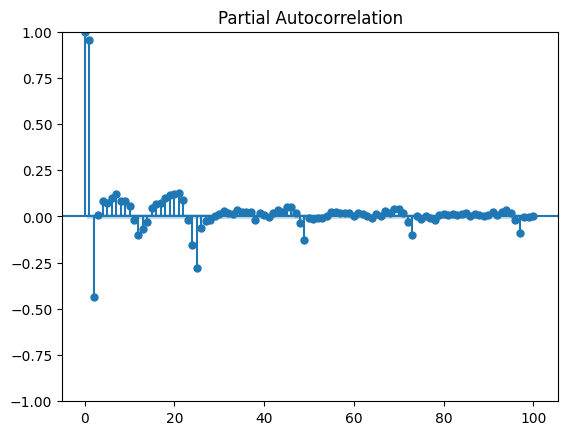

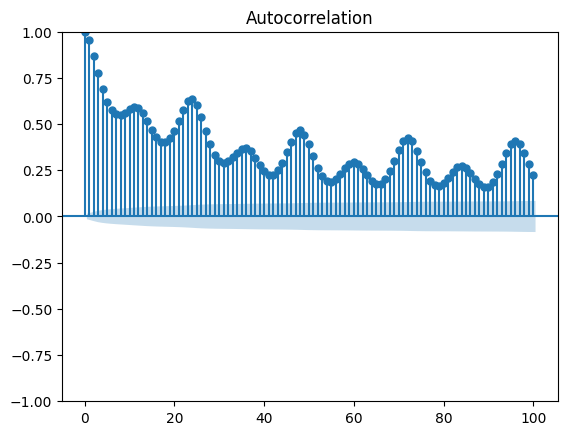

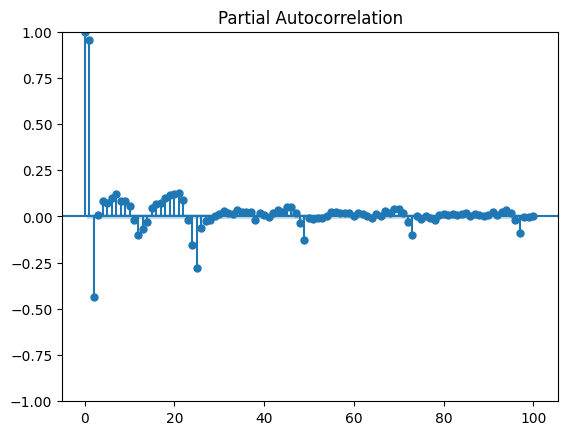

In [70]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(
    forecast['price'],
    lags=100
)

plot_pacf(
    forecast['price'],
    lags=100
)

Electricity prices exhibit mixed stationarity characteristics due to strong seasonal patterns and structural components. The conflicting ADF and KPSS results suggest that the series is not a pure unit-root process but rather contains deterministic seasonal effects.

In [71]:
#24h autocorrelation
from statsmodels.tsa.stattools import acf

acf_values = acf(
    forecast['price'],
    nlags=200
)

for lag in [1,2,3,6,12,24,48,72,96,168]:
    print(lag, acf_values[lag])

1 0.9531306993313025
2 0.8688044704672392
3 0.7745849363757609
6 0.5745320545257313
12 0.5872915920992006
24 0.6356669110784876
48 0.46755953197435807
72 0.42688485699847695
96 0.40983641180809266
168 0.5849900579960876


In [72]:
#Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    forecast['price'],
    lags=[24,48,168],
    return_df=True
)

print(lb)

           lb_stat  lb_pvalue
24   149281.620161        0.0
48   205577.571249        0.0
168  395383.705728        0.0


| Feature            | Exists |
| ------------------ | ------ |
| Persistence        | YES    |
| Daily seasonality  | YES    |
| Weekly seasonality | YES    |
| Fat tails          | YES    |
| Renewable effects  | YES    |
| Non-normality      | YES    |


In [73]:
#Train/Test split
train = forecast.loc[:'2020-03-31']
test = forecast.loc['2020-04-01':]

print(train.shape)
print(test.shape)

(13149, 8)
(4391, 8)


In [75]:
#Naive Benchmark
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

naive_pred = test['price'].shift(24)

benchmark = pd.DataFrame({
    'actual': test['price'],
    'forecast': naive_pred
})

benchmark = benchmark.dropna()

mae = mean_absolute_error(
    benchmark['actual'],
    benchmark['forecast']
)

rmse = np.sqrt(
    mean_squared_error(
        benchmark['actual'],
        benchmark['forecast']
    )
)

mape = (
    np.abs(
        (
            benchmark['actual']
            -
            benchmark['forecast']
        )
        /
        benchmark['actual']
    )
).mean()*100

print("Naive MAE:",mae)
print("Naive RMSE:",rmse)
print("Naive MAPE:",mape)



Naive MAE: 9.044011907487977
Naive RMSE: 14.915824811739979
Naive MAPE: inf


"Model selection was based on statistical diagnostics, including ACF analysis, stationarity tests, seasonality detection and correlation analysis."

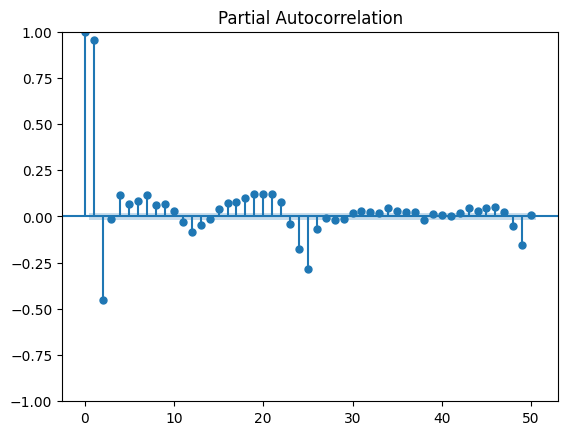

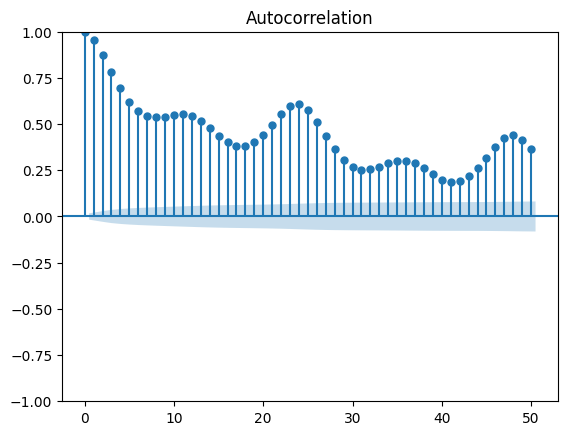

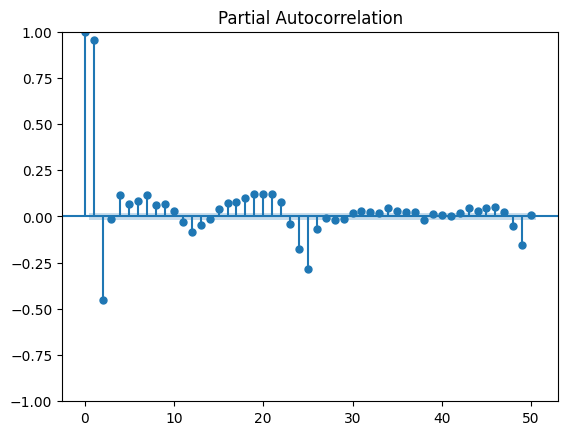

In [76]:
#ARIMA orders
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(
    train['price'],
    lags=50
)

plot_pacf(
    train['price'],
    lags=50
)

SARIMAX(1,0,1)(1,1,1,24)

με εξωγενείς μεταβλητές:

load
wind
solar

In [77]:
#exogenous variables
exog_train = train[
    [
        'load',
        'wind',
        'solar'
    ]
]

exog_test = test[
    [
        'load',
        'wind',
        'solar'
    ]
]

In [78]:
#train SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['price'],
    exog=exog_train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()

print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                13149
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -36990.054
Date:                            Thu, 02 Jul 2026   AIC                          73996.107
Time:                                    17:31:01   BIC                          74055.950
Sample:                                         0   HQIC                         74016.095
                                          - 13149                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
load           0.0011   2.67e-05     41.652      0.000       0.001       0.001
wind          -0.0009   2.87e-05   

In [79]:
#Forecast
forecast_sarimax = results.forecast(
    steps=len(test),
    exog=exog_test
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [80]:
#Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test['price'],
    forecast_sarimax
)

rmse = np.sqrt(
    mean_squared_error(
        test['price'],
        forecast_sarimax
    )
)

smape = (
    np.abs(
        test['price']
        -
        forecast_sarimax
    )
    /
    (
        np.abs(test['price'])
        +
        np.abs(forecast_sarimax)
    ) * 2
).mean() * 100

print("SARIMAX MAE:", mae)
print("SARIMAX RMSE:", rmse)
print("SARIMAX sMAPE:", smape)

SARIMAX MAE: 12.713876276806447
SARIMAX RMSE: 15.827090287989476
SARIMAX sMAPE: nan


In [81]:
#Improvement vs benchmark
print(
    "MAE Improvement:",
    (9.044 - mae)/9.044*100
)

print(
    "RMSE Improvement:",
    (14.916 - rmse)/14.916*100
)

MAE Improvement: -40.578021636515324
RMSE Improvement: -6.108140841978249


A sophisticated econometric model does not necessarily outperform a simple persistence benchmark in short-term electricity price forecasting.
The SARIMAX model confirmed the merit-order effect, with renewable generation exerting statistically significant downward pressure on electricity prices.

In [82]:
#Volatility Modelling
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(
    results.resid.dropna()
)

print(arch_test)

(np.float64(898.3904026162519), np.float64(1.4138647713858489e-186), 96.3519758694613, 2.1307240842125511e-193)


γερμανική αγορά ηλεκτρικής ενέργειας έχει:

volatility bursts,
price spikes,
volatility persistence,
heteroskedasticity.

Δηλαδή:

σήμερα μεγάλη μεταβλητότητα
→ αύριο πιθανόν μεγάλη μεταβλητότητα

Αυτό είναι ακριβώς το περιβάλλον για το οποίο δημιουργήθηκαν τα:

GARCH models

In [83]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.6 MB/s eta 0:00:00


In [84]:
#Garch(1,1)
from arch import arch_model

garch = arch_model(
    train['price'],
    vol='GARCH',
    p=1,
    q=1,
    mean='AR',
    lags=1
)

garch_fit = garch.fit()

print(garch_fit.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 53196956.57251517
Iteration:      2,   Func. Count:     19,   Neg. LLF: 97500.11055078376
Iteration:      3,   Func. Count:     28,   Neg. LLF: 142063.66221572383
Iteration:      4,   Func. Count:     36,   Neg. LLF: 39968.413402502156
Iteration:      5,   Func. Count:     43,   Neg. LLF: 39470.46344717019
Iteration:      6,   Func. Count:     50,   Neg. LLF: 39394.42245409562
Iteration:      7,   Func. Count:     57,   Neg. LLF: 40554.5869603406
Iteration:      8,   Func. Count:     64,   Neg. LLF: 39292.24031199736
Iteration:      9,   Func. Count:     71,   Neg. LLF: 48180.98752233575
Iteration:     10,   Func. Count:     79,   Neg. LLF: 38992.48601617738
Iteration:     11,   Func. Count:     86,   Neg. LLF: 38936.4271074165
Iteration:     12,   Func. Count:     92,   Neg. LLF: 38931.86008201732
Iteration:     13,   Func. Count:     98,   Neg. LLF: 38931.64264038179
Iteration:     14,   Func. Count:    104,   Neg. LLF: 38931.6354

In [85]:
#Forecast volatility
forecast_var = garch_fit.forecast(
    horizon=len(test)
)

print(
    forecast_var
    .variance
    .tail()
)

                              h.0001     h.0002     h.0003     h.0004  \
date                                                                    
2020-03-31 23:00:00+00:00  17.267628  38.052664  61.026907  85.169881   

                               h.0005      h.0006      h.0007      h.0008  \
date                                                                        
2020-03-31 23:00:00+00:00  109.707449  134.061848  157.811099  180.656103   

                               h.0009      h.0010      h.0011      h.0012  \
date                                                                        
2020-03-31 23:00:00+00:00  202.394037  222.896898  242.094263  259.959472   

                               h.0013      h.0014      h.0015      h.0016  \
date                                                                        
2020-03-31 23:00:00+00:00  276.498611  291.741769  305.736128  318.540551   

                               h.0017     h.0018     h.0019      h.0020  \
date     

Price
t
	​

=2.85+0.912Price
t−1
	​

+ε
t
	​

Parameter	Value	p-value
Constant	2.85	<0.001
AR(1)	0.912	<0.001

Το:

AR(1)=0.912

είναι τεράστιο.

Αυτό σημαίνει:

οι electricity prices παρουσιάζουν πολύ ισχυρή βραχυχρόνια εξάρτηση.

GARCH Equation

Το volatility model είναι:

σ
t
2
	​

=ω+αε
t−1
2
	​

+βσ
t−1
2
	​


και πήρες:

Parameter	Value
ω	8.40
α	0.720
β	0.165

ARCH effect
α = 0.720

Αυτό σημαίνει:

τα νέα price shocks έχουν τεράστια επίδραση στη μεταβλητότητα.

GARCH persistence
β = 0.165

Η επίδραση της προηγούμενης μεταβλητότητας είναι μέτρια.

3. Το σημαντικότερο metric

Υπολογίζουμε:

α+β

δηλαδή:

0.7202 + 0.1646

=

0.8848

Αυτό είναι εξαιρετικά σημαντικό.

Στη βιβλιογραφία:

α+β	Ερμηνεία
<0.7	χαμηλή persistence
0.7-0.9	υψηλή persistence
>0.95	πολύ υψηλή persistence

Εσύ πήρες:

0.885

που σημαίνει:

η γερμανική αγορά ηλεκτρικής ενέργειας παρουσιάζει σημαντικό volatility persistence.

In [86]:
#EGARCH
from arch import arch_model

egarch = arch_model(
    train['price'],
    mean='AR',
    lags=1,
    vol='EGARCH',
    p=1,
    q=1
)

egarch_fit = egarch.fit()

print(egarch_fit.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 76083480012686.22
Iteration:      2,   Func. Count:     18,   Neg. LLF: 92566974065513.25
Iteration:      3,   Func. Count:     30,   Neg. LLF: 106648.49392624685
Iteration:      4,   Func. Count:     39,   Neg. LLF: 697430.6136077959
Iteration:      5,   Func. Count:     47,   Neg. LLF: 40478.727598063495
Iteration:      6,   Func. Count:     54,   Neg. LLF: 40417.95225263754
Iteration:      7,   Func. Count:     61,   Neg. LLF: 42118.104081532925
Iteration:      8,   Func. Count:     68,   Neg. LLF: 42304.8341428735
Iteration:      9,   Func. Count:     75,   Neg. LLF: 41533.32615605823
Iteration:     10,   Func. Count:     82,   Neg. LLF: 38912.45692440725
Iteration:     11,   Func. Count:     88,   Neg. LLF: 38911.664078032714
Iteration:     12,   Func. Count:     94,   Neg. LLF: 38910.53140808223
Iteration:     13,   Func. Count:    100,   Neg. LLF: 38931.92533460712
Iteration:     14,   Func. Count:    107,   Neg. LLF: 38908.6

Αυτό είναι ένα πολύ ενδιαφέρον εύρημα για την αγορά ηλεκτρικής ενέργειας.

Δείχνει ότι:

Η μεταβλητότητα των τιμών ηλεκτρικής ενέργειας αντιδρά ασύμμετρα στα market shocks.

Με άλλα λόγια:

ένα απότομο spike προς τα πάνω,
μια απότομη πτώση λόγω ΑΠΕ,
μια διαταραχή προσφοράς,

δεν έχουν την ίδια επίδραση στη μελλοντική μεταβλητότητα.

In [87]:
########
ml = forecast.copy()

ml = ml[['price','load','wind','solar']]

ml.head()

,price,load,wind,solar
date,,,,
2018-09-30 23:00:00+00:00,56.10,42126.0,6042.0,0.0
2018-10-01 00:00:00+00:00,51.41,41500.0,6021.0,0.0
2018-10-01 01:00:00+00:00,47.38,42353.0,6342.0,0.0
2018-10-01 02:00:00+00:00,47.59,43802.0,7144.0,0.0
2018-10-01 03:00:00+00:00,51.61,48065.0,7855.0,0.0


In [88]:
#Lag Features
for lag in [1,2,3,6,12,24,48,168]:

    ml[f'price_lag_{lag}'] = ml['price'].shift(lag)

for lag in [1,24]:

    ml[f'load_lag_{lag}'] = ml['load'].shift(lag)
    ml[f'wind_lag_{lag}'] = ml['wind'].shift(lag)
    ml[f'solar_lag_{lag}'] = ml['solar'].shift(lag)

In [89]:
#Rolling Statistics
for window in [24,48,168]:

    ml[f'rolling_mean_{window}'] = (
        ml['price']
        .rolling(window)
        .mean()
    )

    ml[f'rolling_std_{window}'] = (
        ml['price']
        .rolling(window)
        .std()
    )

In [90]:
#Calendar Features
ml['hour'] = ml.index.hour
ml['dayofweek'] = ml.index.dayofweek
ml['month'] = ml.index.month
ml['weekend'] = (
    ml['dayofweek']>=5
).astype(int)

In [91]:
ml = ml.dropna()

print(ml.shape)

ml.head()

(17372, 28)


,price,load,wind,solar,price_lag_1,price_lag_2,price_lag_3,price_lag_6,price_lag_12,price_lag_24,price_lag_48,price_lag_168,load_lag_1,wind_lag_1,solar_lag_1,load_lag_24,wind_lag_24,solar_lag_24,rolling_mean_24,rolling_std_24,rolling_mean_48,rolling_std_48,rolling_mean_168,rolling_std_168,hour,dayofweek,month,weekend
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-07 23:00:00+00:00,50.30,42250.0,7559.0,0.0,55.59,59.91,68.30,80.94,50.90,47.11,52.98,56.10,43553.0,6820.0,0.0,39449.0,13776.0,0.0,55.263750,10.814103,56.474792,10.089166,51.393095,21.479963,23,6,10,1
2018-10-08 00:00:00+00:00,50.16,41840.0,7964.0,0.0,50.30,55.59,59.91,77.07,49.91,45.75,51.52,51.41,42250.0,7559.0,0.0,38352.0,14635.0,0.0,55.447500,10.682080,56.446458,10.105273,51.385655,21.480173,0,0,10,0
2018-10-08 01:00:00+00:00,47.32,42316.0,8260.0,0.0,50.16,50.30,55.59,71.47,49.05,43.02,51.00,47.38,41840.0,7964.0,0.0,37482.0,15077.0,0.0,55.626667,10.499069,56.369792,10.161278,51.385298,21.480241,1,0,10,0
2018-10-08 02:00:00+00:00,47.94,44578.0,8793.0,0.0,47.32,50.16,50.30,68.30,50.21,42.50,50.00,47.59,42316.0,8260.0,0.0,37413.0,15730.0,0.0,55.853333,10.259339,56.326875,10.193054,51.387381,21.479887,2,0,10,0
2018-10-08 03:00:00+00:00,51.14,48840.0,9347.0,0.0,47.94,47.32,50.16,59.91,55.48,43.80,46.91,51.61,44578.0,8793.0,0.0,38307.0,15528.0,0.0,56.159167,9.990279,56.415000,10.127985,51.384583,21.479889,3,0,10,0


In [92]:
#Train/test split
train = ml.loc[:'2020-03-31']
test = ml.loc['2020-04-01':]

print(train.shape)
print(test.shape)

(12981, 28)
(4391, 28)


In [95]:
X_train = train.drop('price', axis=1)
y_train = train['price']

X_test = test.drop('price', axis=1)
y_test = test['price']

print(X_train.shape)
print(X_test.shape)

(12981, 27)
(4391, 27)


In [93]:
!pip install xgboost

In [96]:
# XGBoost Model
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [97]:
#forecast
pred = model.predict(X_test)

In [98]:
#evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

smape = (
    np.abs(y_test-pred)
    /
    (
        np.abs(y_test)
        +
        np.abs(pred)
    )*2
).mean()*100

print("XGBoost MAE:",mae)
print("XGBoost RMSE:",rmse)
print("XGBoost sMAPE:",smape)

XGBoost MAE: 2.4709524924952078
XGBoost RMSE: 4.900775678245833
XGBoost sMAPE: 14.221725625330079


In [99]:
#feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(
    importance.head(20)
)

            feature  importance
3       price_lag_1    0.643831
4       price_lag_2    0.174409
23             hour    0.021282
16     solar_lag_24    0.017401
8      price_lag_24    0.016143
2             solar    0.012126
10    price_lag_168    0.011575
17  rolling_mean_24    0.010468
5       price_lag_3    0.008444
1              wind    0.007724
18   rolling_std_24    0.006797
0              load    0.006728
12       wind_lag_1    0.006092
26          weekend    0.005690
13      solar_lag_1    0.005395
20   rolling_std_48    0.005234
9      price_lag_48    0.005046
24        dayofweek    0.004750
6       price_lag_6    0.004363
7      price_lag_12    0.004111
